In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 20)

cols = ['survived', 'pclass', 'sex', 'age',
'sibsp', 'parch', 'fare', 'embarked']
df = sns.load_dataset('titanic')[cols].copy()
print("Dataset loaded successfully!")
print("Shape (rows, columns):", df.shape)

Dataset loaded successfully!
Shape (rows, columns): (891, 8)


In [2]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [4]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [5]:
print("Data types:")
print(df.dtypes)
print("\nUnique values per column:")
print(df.nunique())

Data types:
survived      int64
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object

Unique values per column:
survived      2
pclass        3
sex           2
age          88
sibsp         7
parch         7
fare        248
embarked      3
dtype: int64


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing percentage (%):")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

Missing percentage (%):
survived     0.00
pclass       0.00
sex          0.00
age         19.87
sibsp        0.00
parch        0.00
fare         0.00
embarked     0.22
dtype: float64


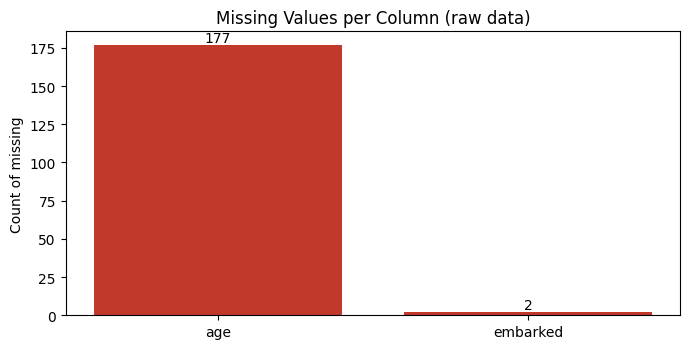

In [7]:
import matplotlib.pyplot as plt
miss = df.isnull().sum()
miss = miss[miss > 0]
plt.figure(figsize=(7, 3.6))
plt.bar(miss.index, miss.values, color='#c0392b')
plt.title('Missing Values per Column (raw data)')
plt.ylabel('Count of missing')
for i, v in enumerate(miss.values):
    plt.text(i, v + 2, str(v), ha='center')
plt.tight_layout()
plt.show()

In [8]:
# Numeric column -> median
df['age'] = df['age'].fillna(df['age'].median())
# Categorical column -> mode (most frequent value)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
print("After imputation, missing values per column:")
print(df.isnull().sum())
print("\nMedian age used:", df['age'].median())

After imputation, missing values per column:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Median age used: 28.0


In [9]:
df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})
print(df[['sex', 'sex_encoded']].head())

      sex  sex_encoded
0    male            0
1  female            1
2  female            1
3  female            1
4    male            0


In [10]:
df = pd.get_dummies(df, columns=['embarked'], prefix='emb', dtype=int)
print(df.head())
print("\nColumns now:", df.columns.tolist())

   survived  pclass     sex   age  sibsp  parch     fare  sex_encoded  emb_C  emb_Q  emb_S
0         0       3    male  22.0      1      0   7.2500            0      0      0      1
1         1       1  female  38.0      1      0  71.2833            1      1      0      0
2         1       3  female  26.0      0      0   7.9250            1      0      0      1
3         1       1  female  35.0      1      0  53.1000            1      0      0      1
4         0       3    male  35.0      0      0   8.0500            0      0      0      1

Columns now: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'sex_encoded', 'emb_C', 'emb_Q', 'emb_S']


In [11]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df[['age_norm', 'fare_norm']] = mm.fit_transform(df[['age', 'fare']])
print(df[['age', 'age_norm', 'fare', 'fare_norm']].head())
print("\nage_norm range:",
round(df['age_norm'].min(), 3), "to", round(df['age_norm'].max(), 3))
print("fare_norm range:",
round(df['fare_norm'].min(), 3), "to", round(df['fare_norm'].max(), 3))

    age  age_norm     fare  fare_norm
0  22.0  0.271174   7.2500   0.014151
1  38.0  0.472229  71.2833   0.139136
2  26.0  0.321438   7.9250   0.015469
3  35.0  0.434531  53.1000   0.103644
4  35.0  0.434531   8.0500   0.015713

age_norm range: 0.0 to 1.0
fare_norm range: 0.0 to 1.0


In [12]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
df[['age_std', 'fare_std']] = ss.fit_transform(df[['age', 'fare']])
print(df[['age', 'age_std', 'fare', 'fare_std']].head())
print("\nage_std mean=%.4f std=%.4f" % (df['age_std'].mean(), df['age_std'].std()))
print("fare_std mean=%.4f std=%.4f" % (df['fare_std'].mean(), df['fare_std'].std()))
                                

    age   age_std     fare  fare_std
0  22.0 -0.565736   7.2500 -0.502445
1  38.0  0.663861  71.2833  0.786845
2  26.0 -0.258337   7.9250 -0.488854
3  35.0  0.433312  53.1000  0.420730
4  35.0  0.433312   8.0500 -0.486337

age_std mean=0.0000 std=1.0006
fare_std mean=0.0000 std=1.0006


In [13]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Q1 =", Q1, " Q3 =", Q3, " IQR =", round(IQR, 4))
print("Lower bound =", round(lower, 4), " Upper bound =", round(upper, 4))
outliers = df[(df['fare'] < lower) | (df['fare'] > upper)]
print("Number of outliers in 'fare':", len(outliers))

Q1 = 7.9104  Q3 = 31.0  IQR = 23.0896
Lower bound = -26.724  Upper bound = 65.6344
Number of outliers in 'fare': 116


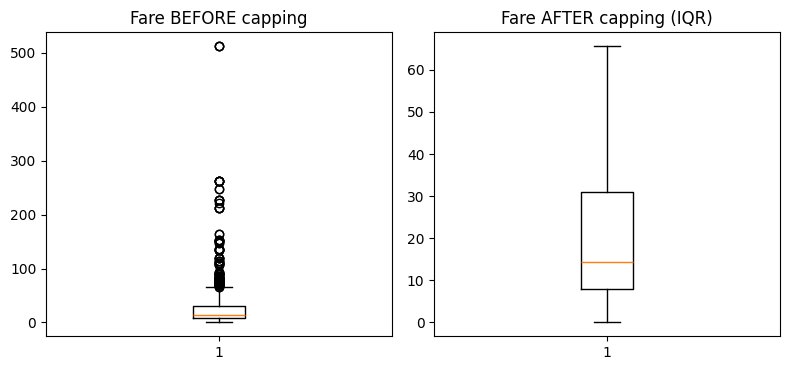

In [14]:
# Capped version for comparison (used in the next step too)
df['fare_capped'] = df['fare'].clip(lower=lower, upper=upper)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))
ax[0].boxplot(df['fare']); ax[0].set_title('Fare BEFORE capping')
ax[1].boxplot(df['fare_capped']); ax[1].set_title('Fare AFTER capping (IQR)')
plt.tight_layout()
plt.show()

In [15]:
print("Before capping -> max fare:", df['fare'].max())
print("After capping -> max fare:", df['fare_capped'].max())
print(df[['fare', 'fare_capped']].sort_values('fare', ascending=False).head())

Before capping -> max fare: 512.3292
After capping -> max fare: 65.6344
         fare  fare_capped
679  512.3292      65.6344
258  512.3292      65.6344
737  512.3292      65.6344
88   263.0000      65.6344
438  263.0000      65.6344


In [16]:
from sklearn.model_selection import train_test_split
feature_cols = ['pclass', 'sex_encoded', 'age', 'sibsp', 'parch',
'fare', 'emb_C', 'emb_Q', 'emb_S']
X = df[feature_cols]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nTraining target balance:")
print(y_train.value_counts(normalize=True).round(3))

X_train shape: (712, 9)
X_test shape: (179, 9)
y_train shape: (712,)
y_test shape: (179,)

Training target balance:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64


In [17]:
final = df[feature_cols + ['survived']]
print("Final preprocessed dataset shape:", final.shape)
print("Any missing values left?", final.isnull().sum().sum())
print(final.head())

Final preprocessed dataset shape: (891, 10)
Any missing values left? 0
   pclass  sex_encoded   age  sibsp  parch     fare  emb_C  emb_Q  emb_S  survived
0       3            0  22.0      1      0   7.2500      0      0      1         0
1       1            1  38.0      1      0  71.2833      1      0      0         1
2       3            1  26.0      0      0   7.9250      0      0      1         1
3       1            1  35.0      1      0  53.1000      0      0      1         1
4       3            0  35.0      0      0   8.0500      0      0      1         0


* #   **Lab Exercises**

* added the dataset freshly


In [18]:
#1
# Reloading a fresh copy
raw = sns.load_dataset('titanic')[cols].copy()

mean_age = raw['age'].mean()
median_age = raw['age'].median()

print("Mean age:", round(mean_age, 4))
print("Median age:", median_age)
print("Larger:", "MEAN" if mean_age > median_age else "MEDIAN")

Mean age: 29.6991
Median age: 28.0
Larger: MEAN


In [19]:
#2
df_ex2 = pd.get_dummies(df, columns=['pclass'], prefix='pclass', dtype=int)
print("Columns now:", df_ex2.columns.tolist())
df_ex2.head()

Columns now: ['survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'sex_encoded', 'emb_C', 'emb_Q', 'emb_S', 'age_norm', 'fare_norm', 'age_std', 'fare_std', 'fare_capped', 'pclass_1', 'pclass_2', 'pclass_3']


,survived,sex,age,sibsp,parch,fare,sex_encoded,emb_C,emb_Q,emb_S,age_norm,fare_norm,age_std,fare_std,fare_capped,pclass_1,pclass_2,pclass_3
0,0,male,22.0,1,0,7.2500,0,0,0,1,0.271174,0.014151,-0.565736,-0.502445,7.2500,0,0,1
1,1,female,38.0,1,0,71.2833,1,1,0,0,0.472229,0.139136,0.663861,0.786845,65.6344,1,0,0
2,1,female,26.0,0,0,7.9250,1,0,0,1,0.321438,0.015469,-0.258337,-0.488854,7.9250,0,0,1
3,1,female,35.0,1,0,53.1000,1,0,0,1,0.434531,0.103644,0.433312,0.420730,53.1000,1,0,0
4,0,male,35.0,0,0,8.0500,0,0,0,1,0.434531,0.015713,0.433312,-0.486337,8.0500,0,0,1


In [20]:
#3
mm = MinMaxScaler()
df[['sibsp_norm', 'parch_norm']] = mm.fit_transform(df[['sibsp', 'parch']])

print(df[['sibsp', 'sibsp_norm', 'parch', 'parch_norm']].head())
print("\nsibsp_norm range:", df['sibsp_norm'].min(), "to", df['sibsp_norm'].max())
print("parch_norm range:", df['parch_norm'].min(), "to", df['parch_norm'].max())

   sibsp  sibsp_norm  parch  parch_norm
0      1       0.125      0         0.0
1      1       0.125      0         0.0
2      0       0.000      0         0.0
3      1       0.125      0         0.0
4      0       0.000      0         0.0

sibsp_norm range: 0.0 to 1.0
parch_norm range: 0.0 to 1.0


In [21]:
#4
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 =", Q1, " Q3 =", Q3, " IQR =", round(IQR, 4))
print("Lower bound =", round(lower, 4), " Upper bound =", round(upper, 4))

age_outliers = df[(df['age'] < lower) | (df['age'] > upper)]
print("Number of outliers in 'age':", len(age_outliers))

df['age_capped'] = df['age'].clip(lower=lower, upper=upper)
print("New maximum age after capping:", df['age_capped'].max())

Q1 = 22.0  Q3 = 35.0  IQR = 13.0
Lower bound = 2.5  Upper bound = 54.5
Number of outliers in 'age': 66
New maximum age after capping: 54.5


In [22]:
#5
feature_cols = ['pclass', 'sex_encoded', 'age', 'sibsp', 'parch',
                'fare', 'emb_C', 'emb_Q', 'emb_S']
X = df[feature_cols]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)


X_train shape: (623, 9)
X_test  shape: (268, 9)
y_train shape: (623,)
y_test  shape: (268,)


In [23]:
#6-combine
def preprocess(df):
    df = df.copy()

    # Step 4: missing values
    df['age'] = df['age'].fillna(df['age'].median())
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

    # Step 5: encoding
    df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})
    df = pd.get_dummies(df, columns=['embarked'], prefix='emb', dtype=int)

    # Step 6: scaling
    mm = MinMaxScaler()
    df[['age_norm', 'fare_norm']] = mm.fit_transform(df[['age', 'fare']])
    ss = StandardScaler()
    df[['age_std', 'fare_std']] = ss.fit_transform(df[['age', 'fare']])

    # Step 7: outlier capping (fare)
    Q1 = df['fare'].quantile(0.25)
    Q3 = df['fare'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df['fare_capped'] = df['fare'].clip(lower=lower, upper=upper)

    # Step 8: train/test split
    feature_cols = ['pclass', 'sex_encoded', 'age', 'sibsp', 'parch',
                     'fare', 'emb_C', 'emb_Q', 'emb_S']
    X = df[feature_cols]
    y = df['survived']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    return X_train, X_test, y_train, y_test

# Test on a fresh copy of the Titanic dataset
fresh_df = sns.load_dataset('titanic')[cols].copy()
X_train, X_test, y_train, y_test = preprocess(fresh_df)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)
print("\nAny missing values in X_train?", X_train.isnull().sum().sum())
print("Training target balance:")
print(y_train.value_counts(normalize=True).round(3))

X_train shape: (712, 9)
X_test  shape: (179, 9)
y_train shape: (712,)
y_test  shape: (179,)

Any missing values in X_train? 0
Training target balance:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64
